In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", palette="deep")

In [ ]:
df = pd.read_csv('node_combined.csv')
df['datetime'] = pd.to_datetime(df['datetime'])

In [ ]:
df.shape
df.info()
df.dtypes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2895 entries, 0 to 2894
Data columns (total 12 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   node       2895 non-null   int64         
 1   location   2895 non-null   object        
 2   weather    2895 non-null   object        
 3   datetime   2895 non-null   datetime64[ns]
 4   h2s        2895 non-null   float64       
 5   so2        2895 non-null   float64       
 6   hum        2895 non-null   float64       
 7   temp       2895 non-null   float64       
 8   windspeed  2895 non-null   float64       
 9   elevation  2895 non-null   float64       
 10  latitude   2895 non-null   float64       
 11  longitude  2895 non-null   float64       
dtypes: datetime64[ns](1), float64(8), int64(1), object(2)
memory usage: 271.5+ KB


,0
node,int64
location,object
weather,object
datetime,datetime64[ns]
h2s,float64
so2,float64
hum,float64
temp,float64
windspeed,float64
elevation,float64


In [ ]:
df.isnull().sum()

,0
node,0
location,0
weather,0
datetime,0
h2s,0
so2,0
hum,0
temp,0
windspeed,0
elevation,0


In [ ]:
df['h2s'].value_counts()
df['h2s'].value_counts(normalize=True)

,proportion
h2s,
4.0,0.143005
7.0,0.099136
9.0,0.054577
12.0,0.050777
15.0,0.048359
...,...
212.0,0.000345
252.0,0.000345
351.0,0.000345


In [ ]:
df['so2'].value_counts()
df['so2'].value_counts(normalize=True)

,proportion
so2,
0.0,0.252850
15.0,0.013817
36.0,0.013126
209.0,0.012435
220.0,0.012435
...,...
508.0,0.000345
717.0,0.000345
576.0,0.000345


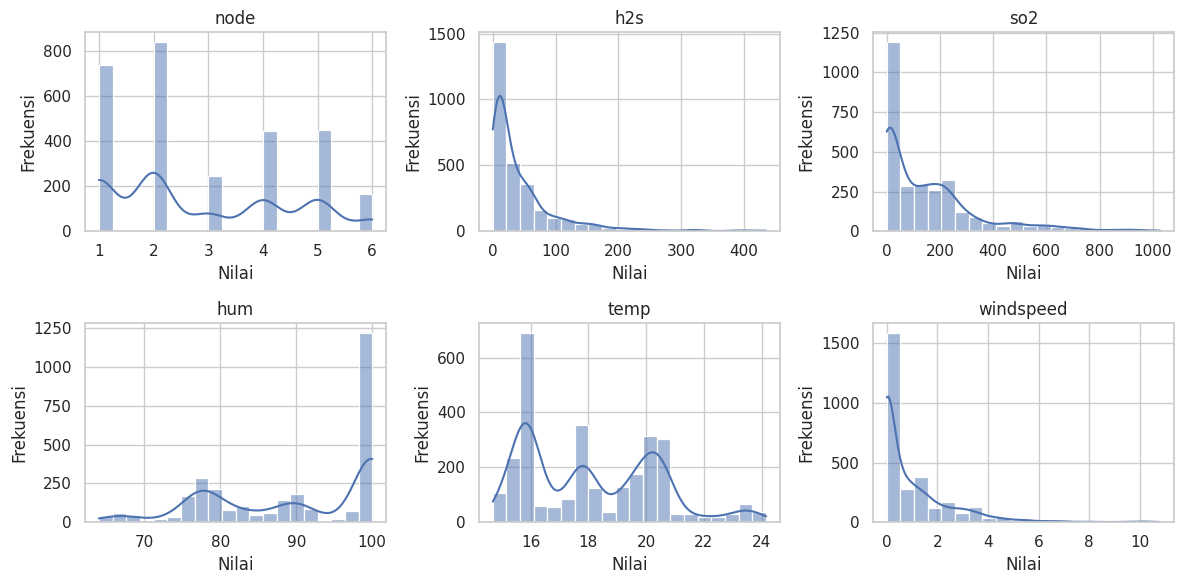

Skewness H2S: 2.89
Skewness SO2: 1.78


In [ ]:
# Menampilkan histogram
fig, axes = plt.subplots(2, 3, figsize=(12, 6))
axes = axes.flatten()

num_cols = ["node", "h2s", "so2", "hum", "temp", "windspeed"]

for i, column in enumerate(num_cols):

    # Tampilkan histogram
    sns.histplot(df[column], bins=20, kde=True, ax=axes[i])

    # Atur judul dan label
    axes[i].set_title(column)
    axes[i].set_xlabel("Nilai")
    axes[i].set_ylabel("Frekuensi")

plt.tight_layout()
plt.show()


print(f"Skewness H2S: {df['h2s'].skew():.2f}")
print(f"Skewness SO2: {df['so2'].skew():.2f}")

**Masalah Potensial:**

- Model bisa belajar untuk **prediksi semua orang gak selamat**, dan tetap dapet akurasi tinggi.
- Tapi itu **model bego**, karena gak bener-bener ngerti siapa yang *selamat*.

> Kayak tebak "semua gagal ujian", padahal lo pengen tahu siapa yang lulus. 🥲
>

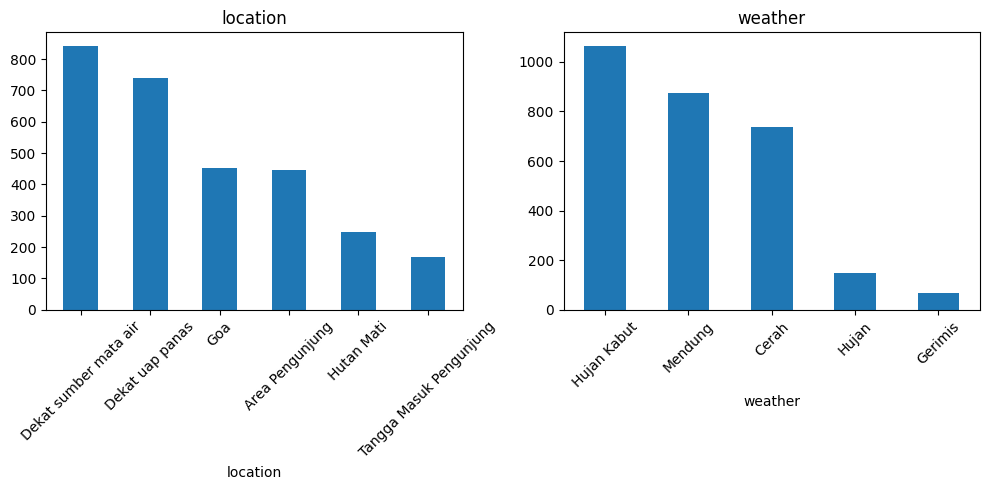

In [ ]:
# Ambil kolom kategorikal
cat_cols = df.select_dtypes(include='object').columns

# Subplot
fig, axes = plt.subplots(nrows=1, ncols=len(cat_cols), figsize=(5 * len(cat_cols), 5))

# Pastikan axes selalu iterable
if len(cat_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, cat_cols):
    df[col].value_counts().plot(kind='bar', ax=ax)
    ax.set_title(col)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45)

plt.tight_layout()
plt.show()


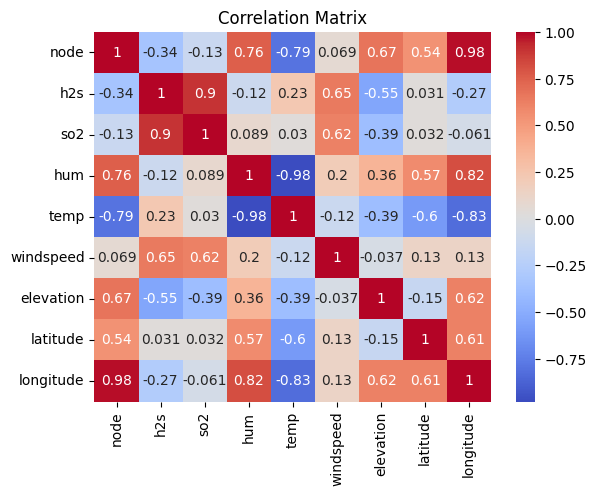

In [ ]:
# Correlation matrix
corr = df.select_dtypes(include='number').corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

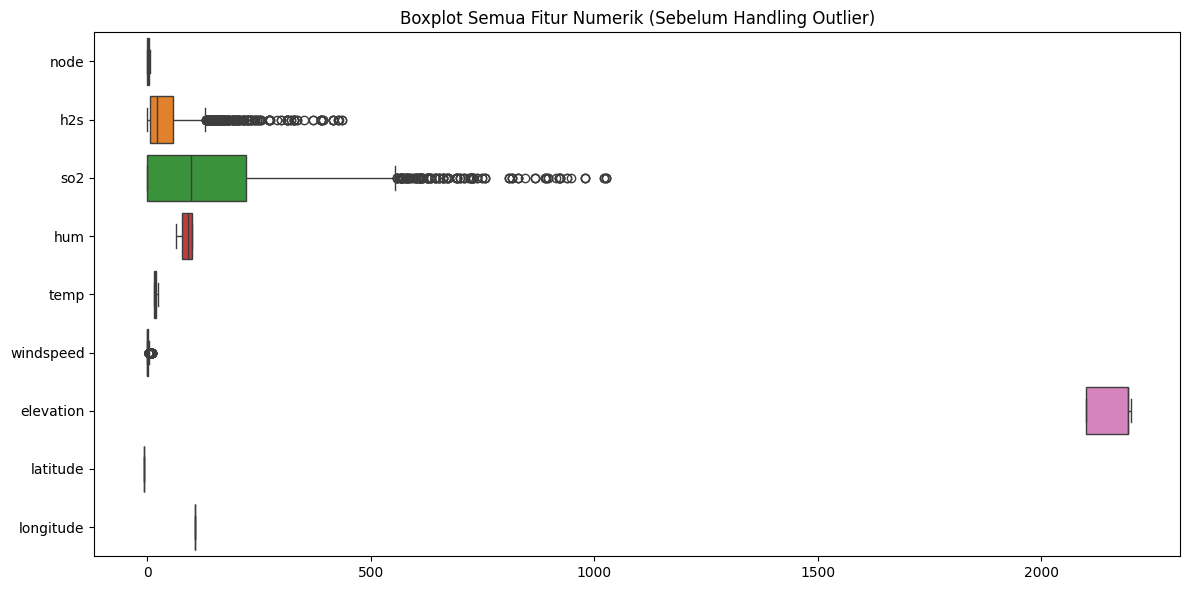

Jumlah outlier per kolom sebelum handling:
node: 0
h2s: 232
so2: 152
hum: 0
temp: 0
windspeed: 160
elevation: 0
latitude: 0
longitude: 0


In [ ]:
## Cek outlier
from sklearn.preprocessing import RobustScaler

# --- Pilih kolom numerik ---
num_cols = df.select_dtypes(include="number").columns

# --- Convert kolom ke numeric (handle string / unknown) ---
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')  # invalid -> NaN

# isi NaN dengan median supaya bisa cek outlier
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Visualisasi boxplot sebelum handling
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[num_cols], orient='h')
plt.title("Boxplot Semua Fitur Numerik (Sebelum Handling Outlier)")
plt.tight_layout()
plt.show()

# Hitung jumlah outlier per kolom pakai IQR
outlier_summary = {}
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary[col] = outliers

print("Jumlah outlier per kolom sebelum handling:")
for k, v in outlier_summary.items():
    print(f"{k}: {v}")


In [ ]:
df_ts=df.groupby("datetime")[["h2s", "so2"]].sum().reset_index()

In [ ]:
df_ts.tail()

,datetime,h2s,so2
2890,2025-12-22 16:43:24,7.0,65.0
2891,2025-12-22 16:43:26,7.0,65.0
2892,2025-12-22 16:43:28,7.0,62.0
2893,2025-12-22 16:43:30,7.0,62.0
2894,2025-12-22 16:43:32,7.0,65.0


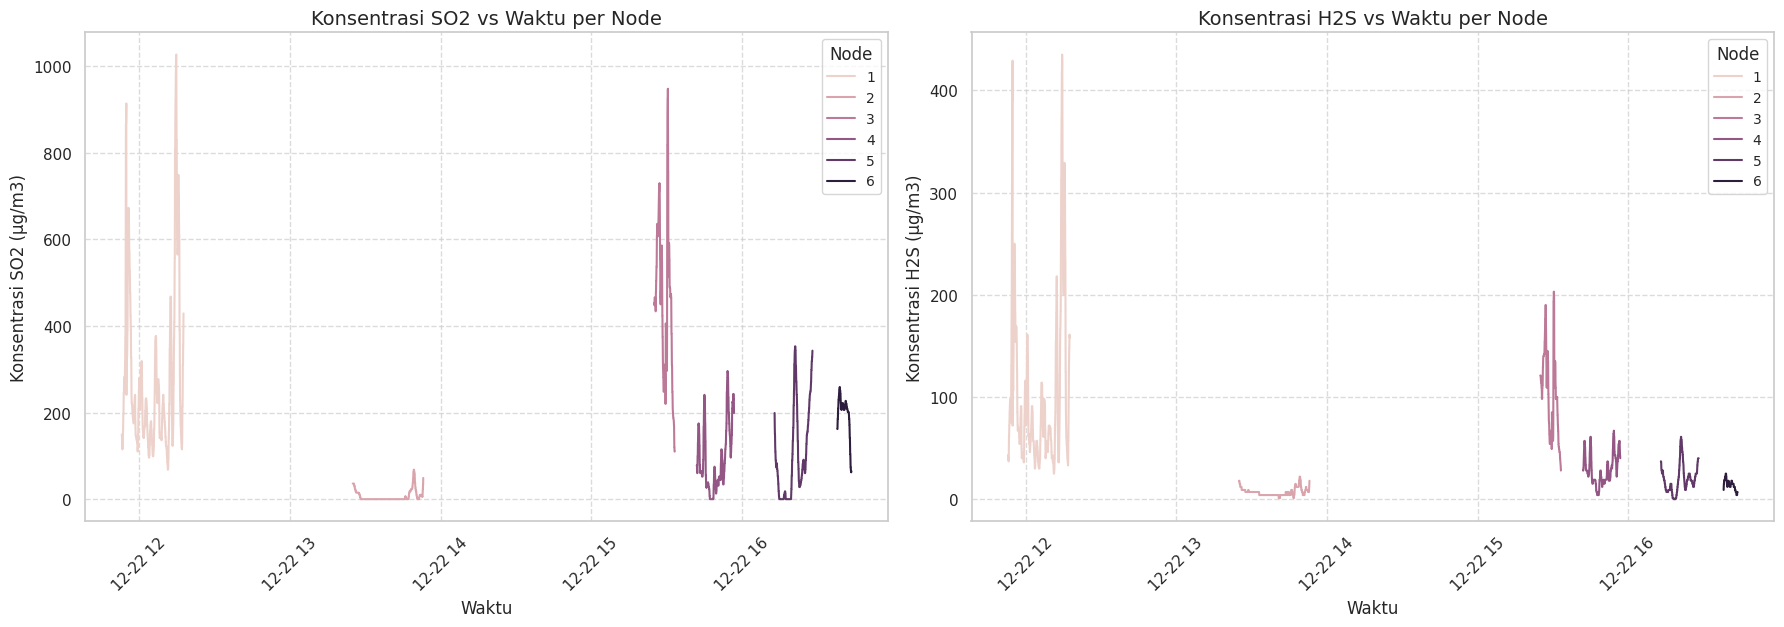

In [ ]:
# Create subplots for better separation and scientific clarity
fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharex=True, sharey=False)

# plot SO2
sns.lineplot(data=df, x="datetime", y="so2", hue="node", ax=axes[0])
axes[0].set_title("Konsentrasi SO2 vs Waktu per Node", fontsize=14)
axes[0].set_xlabel("Waktu", fontsize=12)
axes[0].set_ylabel("Konsentrasi SO2 (μg/m3)", fontsize=12)
axes[0].legend(title="Node", fontsize=10, title_fontsize=12)
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, linestyle='--', alpha=0.7)

# plot H2S
sns.lineplot(data=df, x="datetime", y="h2s", hue="node", ax=axes[1])
axes[1].set_title("Konsentrasi H2S vs Waktu per Node", fontsize=14)
axes[1].set_xlabel("Waktu", fontsize=12)
axes[1].set_ylabel("Konsentrasi H2S (μg/m3)", fontsize=12)
axes[1].legend(title="Node", fontsize=10, title_fontsize=12)
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()